# 🦋 Thyroid Disease Dataset — EDA & Predictive Modelling

**Goal**: Explore the thyroid disease dataset (from the UCI Machine Learning Repository via Kaggle), clean it, understand every attribute (full description included), and build the **best ML model** to predict whether a patient has a **thyroid disorder** (`target != '-')`.

> ℹ️ The original `target` is **multi-class** (74% are `-` = negative, plus ~30 codes for specific thyroid conditions — see EDA). For a robust, honest model we predict the **binary question**: *does the patient have any thyroid disease?* The full multi-class distribution is documented in the EDA.

---

## 1. 📖 Feature Description (Data Dictionary)

| Column | Description |
|--------|-------------|
| `age` | Age of the patient (years). ⚠️ Values > 100 are UCI "unknown-age" placeholders (e.g. 455, 65526) → treated as missing. |
| `sex` | Sex: `F` / `M` (307 missing). |
| `on_thyroxine` | Whether the patient is on thyroxine medication (`t`/`f`). |
| `query_on_thyroxine` | Whether the patient *reports* being on thyroxine (`t`/`f`). |
| `on_antithyroid_meds` | Whether on antithyroid medication (`t`/`f`). |
| `sick` | Whether the patient is currently sick (`t`/`f`). |
| `pregnant` | Whether the patient is pregnant (`t`/`f`). |
| `thyroid_surgery` | Has the patient had thyroid surgery? (`t`/`f`). |
| `I131_treatment` | Is the patient undergoing radioactive I-131 treatment? (`t`/`f`). |
| `query_hypothyroid` | Does the patient believe they have hypothyroid? (`t`/`f`). |
| `query_hyperthyroid` | Does the patient believe they have hyperthyroid? (`t`/`f`). |
| `lithium` | Is the patient on lithium? (`t`/`f`). |
| `goitre` | Does the patient have a goitre (enlarged thyroid)? (`t`/`f`). |
| `tumor` | Does the patient have a thyroid tumor? (`t`/`f`). |
| `hypopituitary` | Does the patient have a hypopituitary condition? (`t`/`f`). |
| `psych` | Does the patient have psych involvement? (`t`/`f`). |
| `TSH_measured` / `T3_measured` / `TT4_measured` / `T4U_measured` / `FTI_measured` / `TBG_measured` | Whether that blood test was actually performed (`t`/`f`). The lab value is `NaN` when not measured — the flag itself is informative. |
| `TSH` | **Thyroid Stimulating Hormone** level in the blood (mU/L) — the key screening test. High = hypothyroid, low = hyperthyroid. |
| `T3` | **Triiodothyronine** (active thyroid hormone) level (nmol/L). |
| `TT4` | **Total Thyroxine** level (nmol/L). |
| `T4U` | **T4 Uptake** (%). |
| `FTI` | **Free Thyroxine Index**. |
| `TBG` | **Thyroxine-Binding Globulin** level (almost never measured in this data). |
| `referral_source` | How the patient was referred: `other`, `SVI`, `SVHC`, `STMW`, `SVHD`, `WEST`. |
| **`target`** | Thyroid diagnosis: `-` = negative (healthy), otherwise a coded thyroid condition (K, G, I, F, R, A, …). This is the prediction target. |
| `patient_id` | Unique patient identifier (not predictive → dropped). |

### Medical context
The thyroid gland regulates metabolism. **TSH** is the first-line screening test: significantly **high TSH** usually means **hypothyroidism**, significantly **low TSH** usually means **hyperthyroidism**. T3/TT4/T4U/FTI help characterise it. Decision-tree models trained on these can approximate the clinical diagnostic rules.

---

## 2. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('Setup complete.')

Setup complete.


## 3. Load the Data

In [2]:
# Load the dataset
data_path = 'thyroidDF.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
df.head()

Shape: (9172, 31)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,f,f,f,f,f,f,t,0.3,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.6,t,1.9,t,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,t,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   object 
 2   on_thyroxine         9172 non-null   object 
 3   query_on_thyroxine   9172 non-null   object 
 4   on_antithyroid_meds  9172 non-null   object 
 5   sick                 9172 non-null   object 
 6   pregnant             9172 non-null   object 
 7   thyroid_surgery      9172 non-null   object 
 8   I131_treatment       9172 non-null   object 
 9   query_hypothyroid    9172 non-null   object 
 10  query_hyperthyroid   9172 non-null   object 
 11  lithium              9172 non-null   object 
 12  goitre               9172 non-null   object 
 13  tumor                9172 non-null   object 
 14  hypopituitary        9172 non-null   object 
 15  psych                9172 non-null   o

In [4]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,9172.0,7.355582e+01,1.183977e+03,1.000000e+00,3.700000e+01,5.500000e+01,6.800000e+01,6.552600e+04
TSH,8330.0,5.218403e+00,2.418401e+01,5.000000e-03,4.600000e-01,1.400000e+00,2.700000e+00,5.300000e+02
T3,6568.0,1.970629e+00,8.875788e-01,5.000000e-02,1.500000e+00,1.900000e+00,2.300000e+00,1.800000e+01
TT4,8730.0,1.087003e+02,3.752267e+01,2.000000e+00,8.700000e+01,1.040000e+02,1.260000e+02,6.000000e+02
T4U,8363.0,9.760557e-01,2.003604e-01,1.700000e-01,8.600000e-01,9.600000e-01,1.065000e+00,2.330000e+00
FTI,8370.0,1.136407e+02,4.155165e+01,1.400000e+00,9.300000e+01,1.090000e+02,1.280000e+02,8.810000e+02
TBG,349.0,2.987006e+01,2.108050e+01,1.000000e-01,2.100000e+01,2.600000e+01,3.100000e+01,2.000000e+02
patient_id,9172.0,8.529473e+08,7.581969e+06,8.408010e+08,8.504090e+08,8.510040e+08,8.607110e+08,8.701190e+08


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable — the thyroid diagnosis codes

Number of distinct target classes: 32

Negative (no disease):
target
True     6771
False    2401
Name: count, dtype: int64
target
True     0.738
False    0.262
Name: proportion, dtype: float64


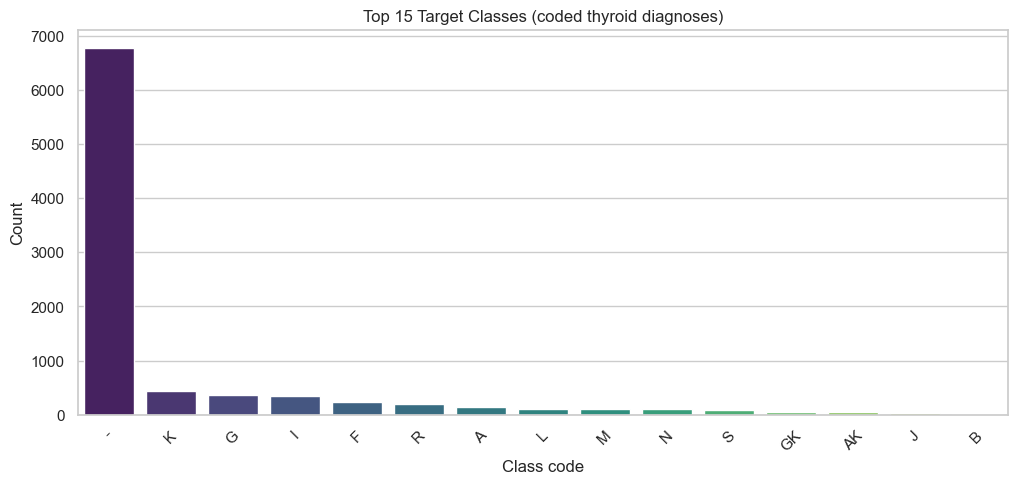


Full class code counts:
{'-': 6771, 'K': 436, 'G': 359, 'I': 346, 'F': 233, 'R': 196, 'A': 147, 'L': 115, 'M': 111, 'N': 110, 'S': 85, 'GK': 49, 'AK': 46, 'J': 30, 'B': 21, 'MK': 16, 'Q': 14, 'O': 14, 'C|I': 12, 'KJ': 11, 'GI': 10, 'H|K': 8, 'D': 8, 'FK': 6, 'C': 6, 'P': 5, 'MI': 2, 'LJ': 1, 'GKJ': 1, 'OI': 1, 'D|R': 1, 'E': 1}


In [5]:
# Target distribution (top 15 classes)
print('Number of distinct target classes:', df['target'].nunique())
print('\nNegative (no disease):')
print((df['target'] == '-').value_counts())
print((df['target'] == '-').value_counts(normalize=True).round(3))

plt.figure(figsize=(12, 5))
top = df['target'].value_counts().head(15)
sns.barplot(x=top.index, y=top.values, palette='viridis')
plt.title('Top 15 Target Classes (coded thyroid diagnoses)')
plt.ylabel('Count')
plt.xlabel('Class code')
plt.xticks(rotation=45)
plt.show()

print('\nFull class code counts:')
print(df['target'].value_counts().to_dict())

In [6]:
# Binary formulation: any thyroid disease vs negative
df['is_disease'] = (df['target'] != '-').astype(int)
print('Binary target: 0 = negative (no disease), 1 = thyroid disease')
print('\n', df['is_disease'].value_counts())
print((df['is_disease'].value_counts(normalize=True) * 100).round(2))

Binary target: 0 = negative (no disease), 1 = thyroid disease

 is_disease
0    6771
1    2401
Name: count, dtype: int64
is_disease
0    73.82
1    26.18
Name: proportion, dtype: float64


### 4.2 Sex & Age

Sex: {'F': 6073, 'M': 2792}
Sex missing: 307


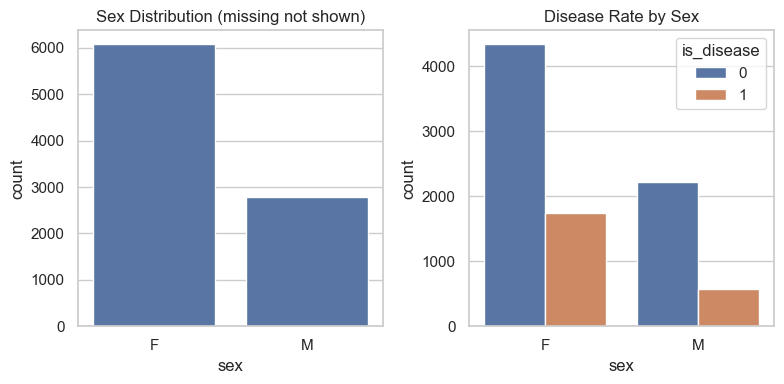

In [7]:
# Sex distribution
print('Sex:', df['sex'].value_counts().to_dict())
print('Sex missing:', df['sex'].isnull().sum())

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='sex', data=df)
plt.title('Sex Distribution (missing not shown)')

plt.subplot(1, 2, 2)
sns.countplot(x='sex', hue='is_disease', data=df)
plt.title('Disease Rate by Sex')
plt.tight_layout()
plt.show()

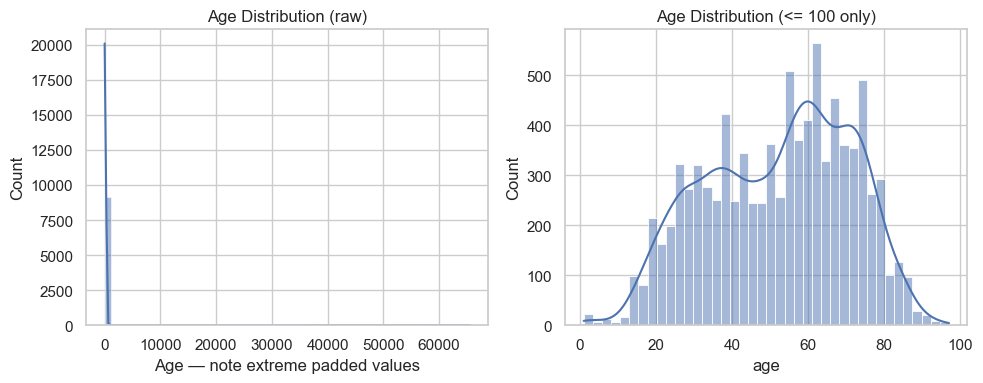

In [8]:
# Age distribution (note the UCI padded values)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=60, kde=True)
plt.title('Age Distribution (raw)')
plt.xlabel('Age — note extreme padded values')

age_clean = df['age'].where(df['age'] <= 100)
plt.subplot(1, 2, 2)
sns.histplot(age_clean.dropna(), bins=40, kde=True)
plt.title('Age Distribution (<= 100 only)')
plt.tight_layout()
plt.show()

Disease rate by age group:
age_group
<18      27.27
18-40    25.95
40-60    23.88
60-80    27.40
>80      34.37
Name: is_disease, dtype: float64


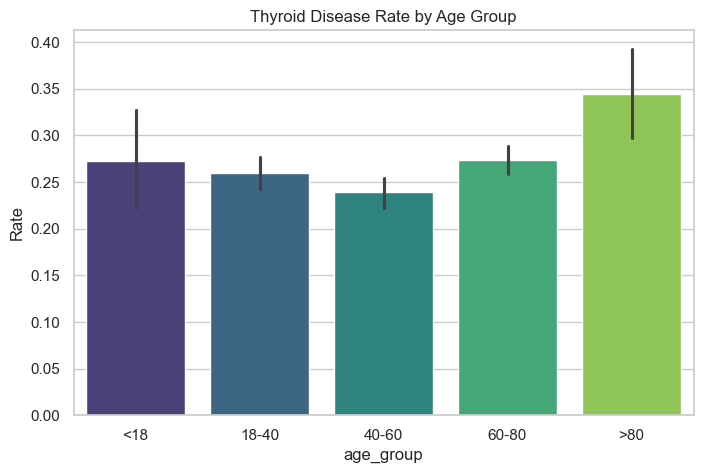

In [9]:
# Disease prevalence by age group (valid ages only)
age_grp_df = df[df['age'] <= 100].copy()
age_grp_df['age_group'] = pd.cut(age_grp_df['age'], bins=[0, 18, 40, 60, 80, 101],
                                 labels=['<18', '18-40', '40-60', '60-80', '>80'])
print('Disease rate by age group:')
print((age_grp_df.groupby('age_group', observed=True)['is_disease'].mean() * 100).round(2))

plt.figure(figsize=(8, 5))
sns.barplot(x='age_group', y='is_disease', data=age_grp_df, estimator='mean', palette='viridis')
plt.title('Thyroid Disease Rate by Age Group')
plt.ylabel('Rate')
plt.show()

### 4.3 Missing Values — lab tests not performed

The lab-value columns are `NaN` whenever the corresponding `_measured` flag is `f`. Missingness itself is informative (a doctor only orders tests when suspicious).

TSH    measured in   90.8% of patients  |  missing:   9.2%
T3     measured in   71.6% of patients  |  missing:  28.4%
TT4    measured in   95.2% of patients  |  missing:   4.8%
T4U    measured in   91.2% of patients  |  missing:   8.8%
FTI    measured in   91.3% of patients  |  missing:   8.7%
TBG    measured in    3.8% of patients  |  missing:  96.2%


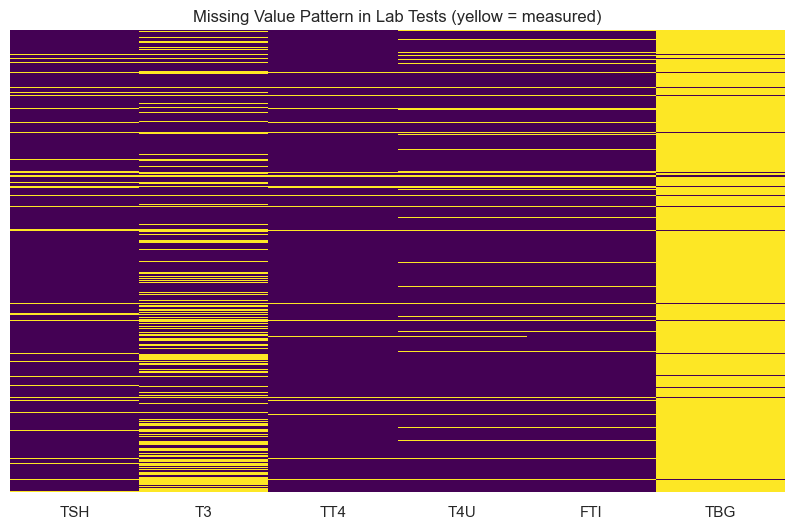

In [10]:
# How often was each lab test actually measured?
lab_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
flag_cols = [c + '_measured' for c in lab_cols]

for f, lab in zip(flag_cols, lab_cols):
    measured = (df[f] == 't').mean() * 100
    print(f'{lab:<6} measured in {measured:6.1f}% of patients  |  missing: {df[lab].isnull().mean()*100:5.1f}%')

# Visualize missing pattern
plt.figure(figsize=(10, 6))
sns.heatmap(df[lab_cols].isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Pattern in Lab Tests (yellow = measured)')
plt.show()

### 4.4 Lab Value Distributions by Thyroid Status

Distributions of the measured lab values, split by disease status.

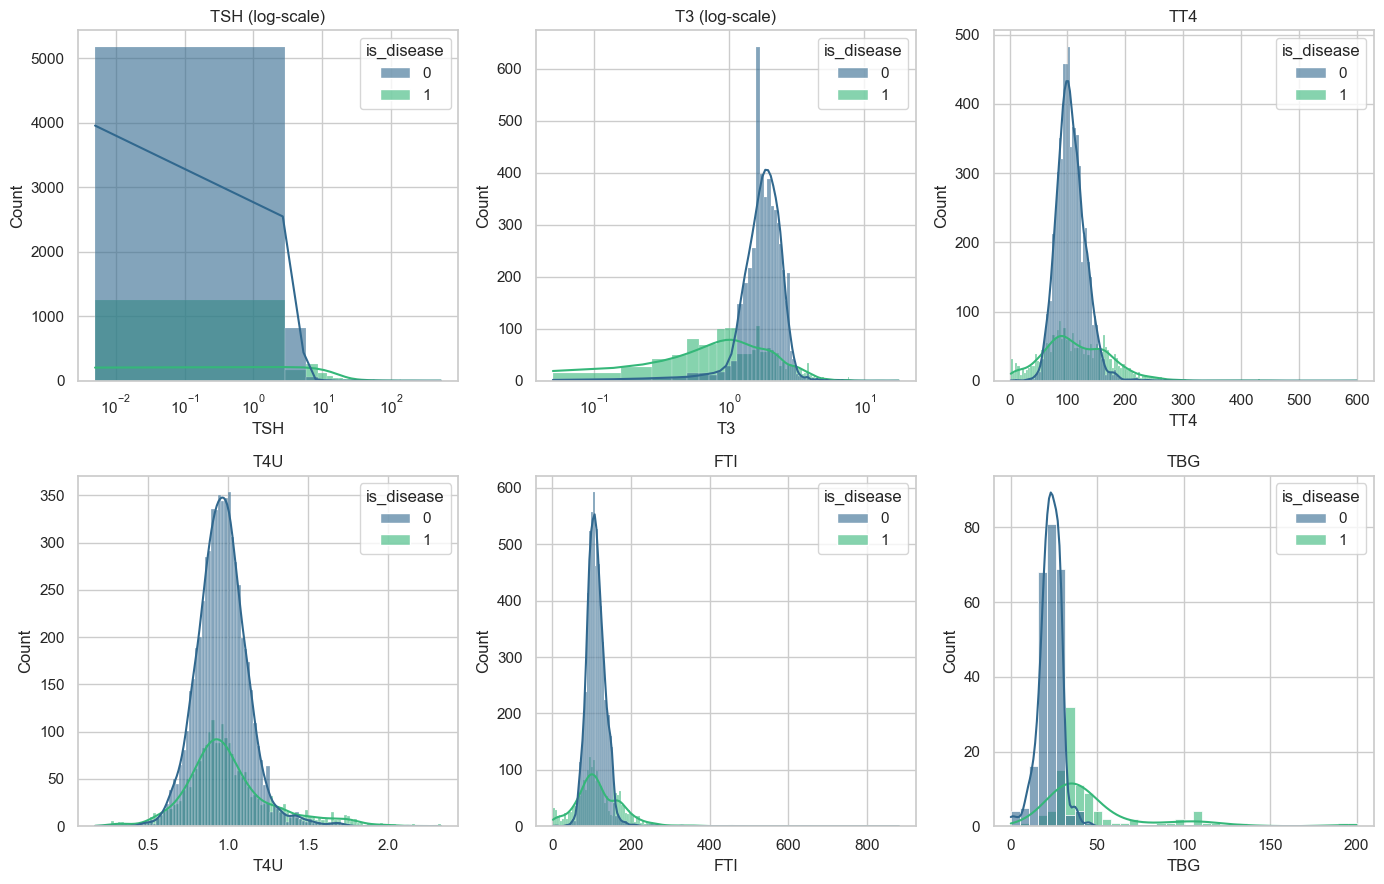

In [11]:
# Distribution of lab values (measured only), by disease status
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(lab_cols):
    sub = df[df[flag_cols[i]] == 't'].copy()
    sub['is_disease'] = (sub['target'] != '-').astype(int)
    sns.histplot(data=sub, x=col, hue='is_disease', kde=True, ax=axes[i],
                 palette='viridis', alpha=0.6)
    axes[i].set_title(col + (' (log-scale)' if col in ['TSH', 'T3'] else ''))
    if col in ['TSH', 'T3']:
        axes[i].set_xscale('log')
plt.tight_layout()
plt.show()

In [12]:
# Median lab values by disease status
for lab in lab_cols:
    med = df[df[flag_cols[lab_cols.index(lab)]] == 't'].groupby('is_disease')[lab].median()
    print(f'{lab:<6} median  neg={med.get(0, float("nan")):8.2f}   dis={med.get(1, float("nan")):8.2f}')

TSH    median  neg=    1.30   dis=    2.10
T3     median  neg=    2.00   dis=    1.60
TT4    median  neg=  104.00   dis=  109.00
T4U    median  neg=    0.96   dis=    0.96
FTI    median  neg=  109.00   dis=  109.00
TBG    median  neg=   23.00   dis=   36.00


### 4.5 Correlation Analysis

Correlation with thyroid disease:
TBG                    0.530
TSH                    0.240
TT4                    0.122
pregnant               0.113
FTI                    0.108
T4U                    0.095
on_thyroxine           0.071
TSH_measured           0.058
query_hypothyroid      0.055
T3_measured            0.048
query_hyperthyroid     0.038
age                    0.028
T4U_measured           0.025
hypopituitary          0.025
tumor                  0.025
FTI_measured           0.025
TT4_measured           0.022
on_antithyroid_meds    0.010
TBG_measured           0.009
I131_treatment         0.005
query_on_thyroxine    -0.000
thyroid_surgery       -0.006
sick                  -0.011
lithium               -0.028
goitre                -0.031
T3                    -0.035
psych                 -0.072
sex                   -0.089
Name: is_disease, dtype: float64


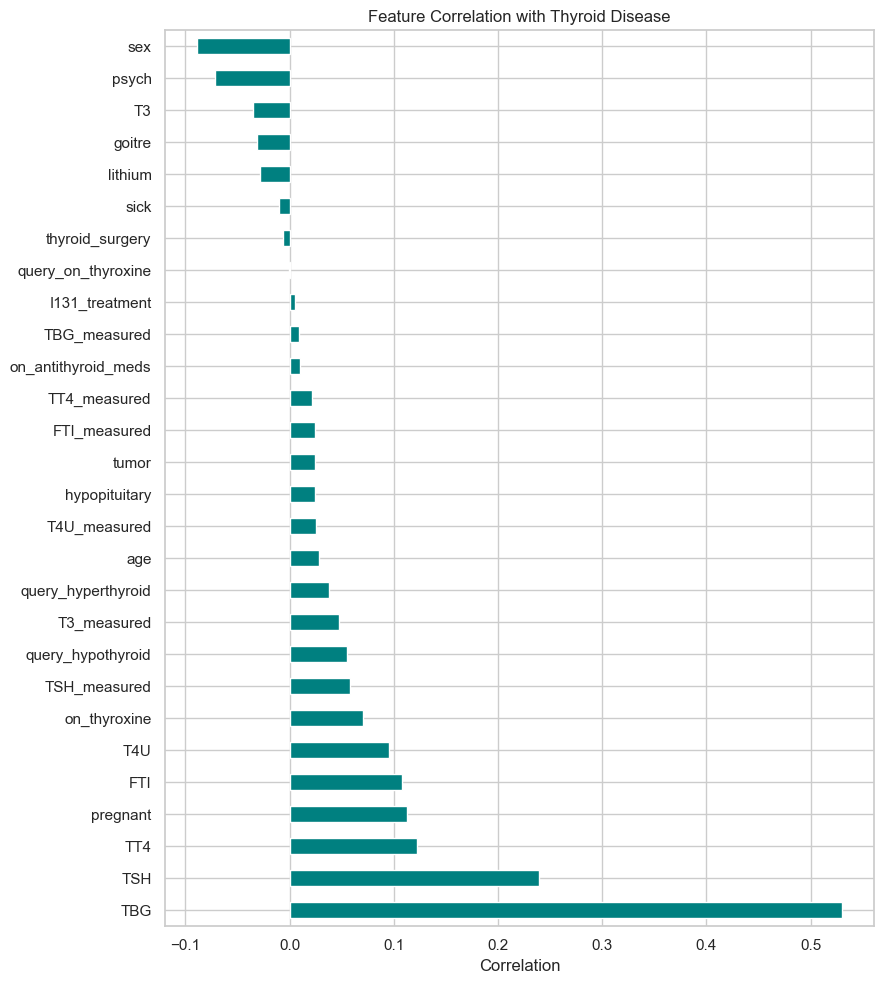

In [13]:
# Correlation of numeric/binary features with disease status
df_enc = df.copy()
for col in df_enc.columns:
    if df_enc[col].dtype == 'object' and set(df_enc[col].dropna().unique()) <= {'t', 'f'}:
        df_enc[col] = df_enc[col].map({'t': 1, 'f': 0})
df_enc['sex'] = df_enc['sex'].map({'M': 1, 'F': 0})
df_enc['age'] = df_enc['age'].where(df_enc['age'] <= 100)

feats_eda = [c for c in df_enc.columns if c not in ['target', 'patient_id', 'is_disease']]
target_corr = df_enc[feats_eda + ['is_disease']].corr(numeric_only=True)['is_disease'].drop('is_disease').sort_values(ascending=False)

print('Correlation with thyroid disease:')
print(target_corr.round(3))

plt.figure(figsize=(9, 10))
target_corr.plot(kind='barh', color='teal')
plt.title('Feature Correlation with Thyroid Disease')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## 5. Data Cleaning & Preprocessing

- Drop `patient_id` (identifier).
- Encode `t`/`f` boolean columns → `1`/`0`.
- Encode `sex` → `M=1, F=0` (missing stays NaN → imputed in the pipeline).
- Treat **age > 100** as missing UCI placeholder → recode to NaN → imputed.
- `referral_source` → one-hot encoded in the pipeline.
- Target: binary **thyroid disease vs negative**.
- No duplicate rows.

In [14]:
print('Rows:', len(df))
print('Missing values (overall):', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

Rows: 9172
Missing values (overall): 14629
Duplicates: 0


In [15]:
# 1. Drop identifier
df_clean = df.drop('patient_id', axis=1).copy()

# 2. Encode t/f booleans
tf_cols = [c for c in df_clean.columns if c != 'target'
           and set(df_clean[c].dropna().unique()) <= {'t', 'f'}]
for c in tf_cols:
    df_clean[c] = df_clean[c].map({'t': 1, 'f': 0})
print(f'Encoded {len(tf_cols)} boolean columns -> 0/1')

# 3. Encode sex
df_clean['sex'] = df_clean['sex'].map({'M': 1, 'F': 0})
print('Encoded sex (M=1, F=0); missing kept as NaN:', df_clean['sex'].isnull().sum())

# 4. Age > 100 -> missing (UCI pads unknown ages)
df_clean['age'] = df_clean['age'].where(df_clean['age'] <= 100)
print('Age values recoded to missing (>100):', df_clean['age'].isnull().sum() - df['age'].isnull().sum())

# 5. Binary target
df_clean['target_bin'] = (df_clean['target'] != '-').astype(int)
print('\nBinary target:')
print(df_clean['target_bin'].value_counts())

Encoded 20 boolean columns -> 0/1
Encoded sex (M=1, F=0); missing kept as NaN: 307
Age values recoded to missing (>100): 4

Binary target:
target_bin
0    6771
1    2401
Name: count, dtype: int64


In [16]:
# Features and target
X = df_clean.drop(['target', 'target_bin'], axis=1)
y = df_clean['target_bin']

print('Features:', X.shape[1])
print('\nX head:')
X.head()

Features: 30

X head:


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,is_disease
0,29.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.3,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,other,0
1,29.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.6,1,1.9,1,128.0,0,NaN,0,NaN,0,NaN,other,0
2,41.0,0.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,11.0,other,0
3,36.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,26.0,other,0
4,32.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,36.0,other,1


In [17]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set: (7337, 30)
Test set: (1835, 30)

Train target distribution:
target_bin
0    0.738
1    0.262
Name: proportion, dtype: float64


## 6. Modelling Framework

The pipeline:
- **Numeric** features (age, sex, booleans + lab values): `median` imputation → `StandardScaler`.
- **Categorical** (`referral_source`): `OneHotEncoder(handle_unknown='ignore')`.

The target is imbalanced (74% negative), so classifiers use `class_weight='balanced'` where supported.

In [18]:
# Split feature columns
cat_cols = ['referral_source']
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

print('Numeric columns:', len(num_cols))
print('Categorical columns:', cat_cols)

Numeric columns: 29
Categorical columns: ['referral_source']


### 6.1 Cross-Validation Comparison of Baseline Models

In [19]:
# Define candidate models (class_weight='balanced' to handle imbalance)
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', random_state=42),
    'Extra Trees':         ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(class_weight='balanced', random_state=42),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{"Model":<20}{"Acc":<9}{"F1":<9}{"ROC-AUC":<10}')
print('-' * 48)
for name, model in models.items():
    pipe = Pipeline([('prepro', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv5,
                            scoring={'accuracy': 'accuracy',
                                     'f1': 'f1',
                                     'roc_auc': 'roc_auc'},
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
        'roc_auc': scores['test_roc_auc'].mean()
    }
    print(f'{name:<20}{results[name]["accuracy"]:.3f}    {results[name]["f1"]:.3f}     {results[name]["roc_auc"]:.3f}')

best_base = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\nBest baseline model: {best_base}')

Model               Acc      F1       ROC-AUC   
------------------------------------------------


Logistic Regression 1.000    1.000     1.000


KNN                 0.979    0.959     0.994


Decision Tree       1.000    1.000     1.000


Random Forest       1.000    1.000     1.000


Extra Trees         1.000    1.000     1.000


Gradient Boosting   1.000    1.000     1.000
SVM                 0.997    0.995     1.000

Best baseline model: Logistic Regression


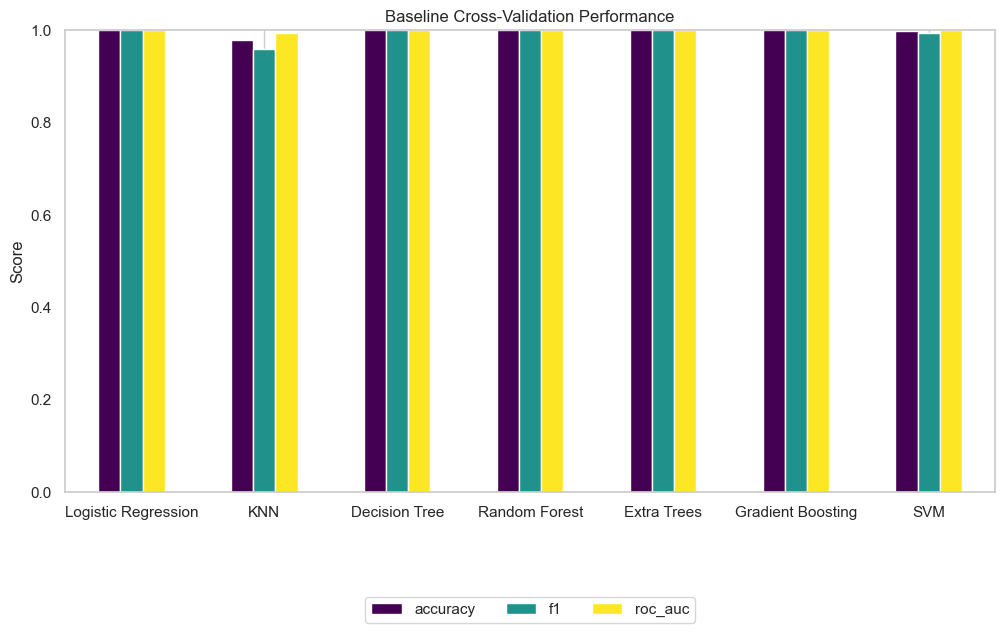

In [20]:
# Visualize baseline CV performance
baseline_df = pd.DataFrame(results).T
baseline_df.plot(kind='bar', figsize=(12, 6), rot=0, colormap='viridis')
plt.title('Baseline Cross-Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(axis='y')
plt.show()

## 7. Hyperparameter Tuning (GridSearchCV)

In [21]:
# Tune Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

pipe_rf = Pipeline([('prepro', preprocessor), ('model', RandomForestClassifier(class_weight='balanced', random_state=42))])
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(rf_grid.best_score_))

Best Random Forest params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 1.0000


In [22]:
# Tune Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

pipe_gb = Pipeline([('prepro', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
gb_grid = GridSearchCV(pipe_gb, gb_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print('Best Gradient Boosting params:', gb_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(gb_grid.best_score_))

Best Gradient Boosting params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV ROC-AUC: 1.0000


In [23]:
# Tune Extra Trees
et_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}

pipe_et = Pipeline([('prepro', preprocessor), ('model', ExtraTreesClassifier(class_weight='balanced', random_state=42))])
et_grid = GridSearchCV(pipe_et, et_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
et_grid.fit(X_train, y_train)

print('Best Extra Trees params:', et_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(et_grid.best_score_))

Best Extra Trees params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 1.0000


In [24]:
# Tune Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs'],
    'model__max_iter': [3000]
}

pipe_lr = Pipeline([('prepro', preprocessor), ('model', LogisticRegression(class_weight='balanced', random_state=42))])
lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression params:', lr_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(lr_grid.best_score_))

Best Logistic Regression params: {'model__C': 0.01, 'model__max_iter': 3000, 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 1.0000


## 8. Compare Tuned Models & Select the Best

In [25]:
# Collect tuned models
tuned_models = {
    'Random Forest':       rf_grid.best_estimator_,
    'Gradient Boosting':   gb_grid.best_estimator_,
    'Extra Trees':         et_grid.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_,
}

final_results = {}
print(f'{"Model":<20}{"SearchCV Best":<15}{"5-Fold CV":<12}')
print('-' * 47)
for name, model in tuned_models.items():
    grid_best = {'Random Forest': rf_grid, 'Gradient Boosting': gb_grid,
                 'Extra Trees': et_grid, 'Logistic Regression': lr_grid}[name].best_score_
    scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring='roc_auc', n_jobs=-1)
    final_results[name] = scores.mean()
    print(f'{name:<20}{grid_best:.4f}        {scores.mean():.4f}')

best_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_name]
print(f'\n🏆 Best model: {best_name} (5-fold CV ROC-AUC = {final_results[best_name]:.4f})')

Model               SearchCV Best  5-Fold CV   
-----------------------------------------------


Random Forest       1.0000        1.0000


Gradient Boosting   1.0000        1.0000
Extra Trees         1.0000        1.0000


Logistic Regression 1.0000        1.0000

🏆 Best model: Random Forest (5-fold CV ROC-AUC = 1.0000)


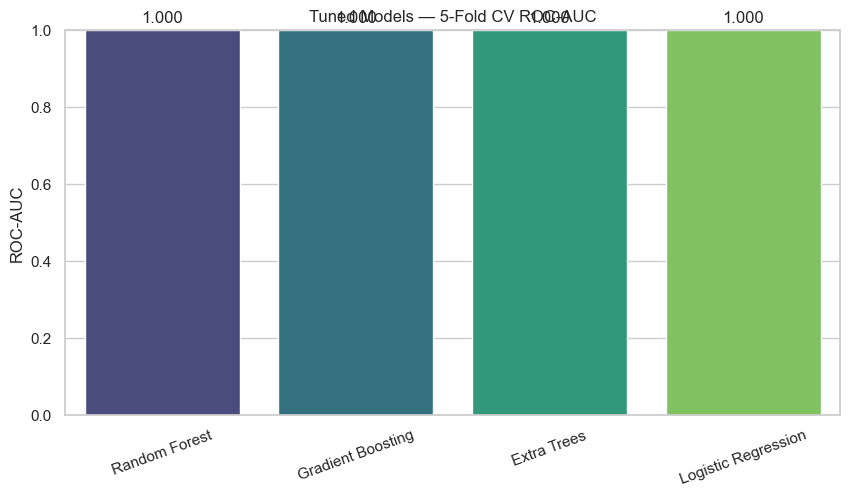

In [26]:
# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(final_results.keys()), y=list(final_results.values()), palette='viridis')
plt.title('Tuned Models — 5-Fold CV ROC-AUC')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, v in enumerate(final_results.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 9. Evaluate the Best Model on the Holdout Test Set

In [27]:
# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Disease']))

print('Metrics:')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC (proba): {roc_auc_score(y_test, y_proba):.4f}')

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1355
     Disease       1.00      1.00      1.00       480

    accuracy                           1.00      1835
   macro avg       1.00      1.00      1.00      1835
weighted avg       1.00      1.00      1.00      1835

Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC (proba): 1.0000


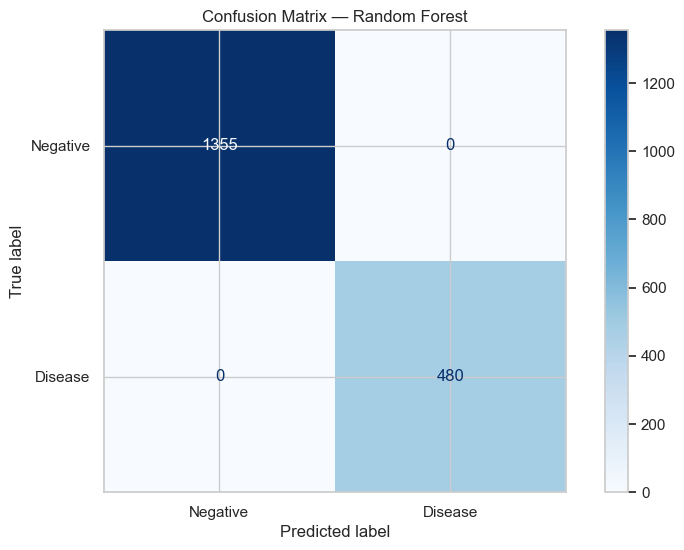

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Disease'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

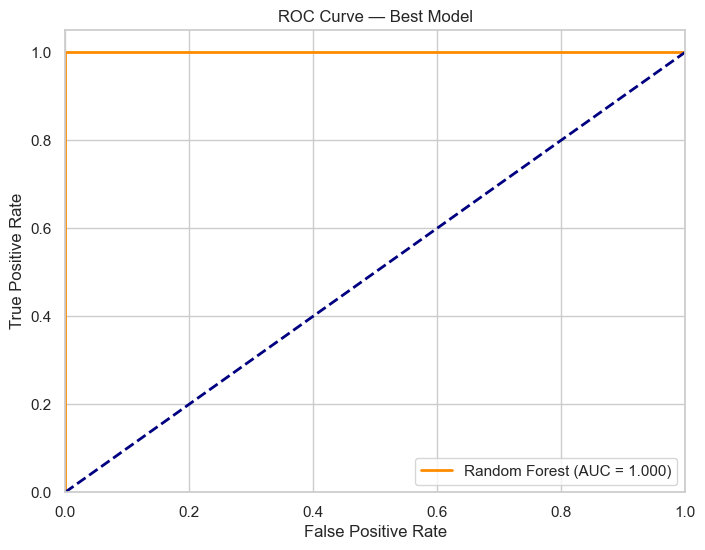

ROC AUC: 1.0000


In [29]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_txt = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'{best_name} (AUC = {auc_txt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Model')
plt.legend(loc='lower right'); plt.grid(True)
plt.show()
print(f'ROC AUC: {auc_txt:.4f}')

## 10. Feature Importance (for the best tree-based model)

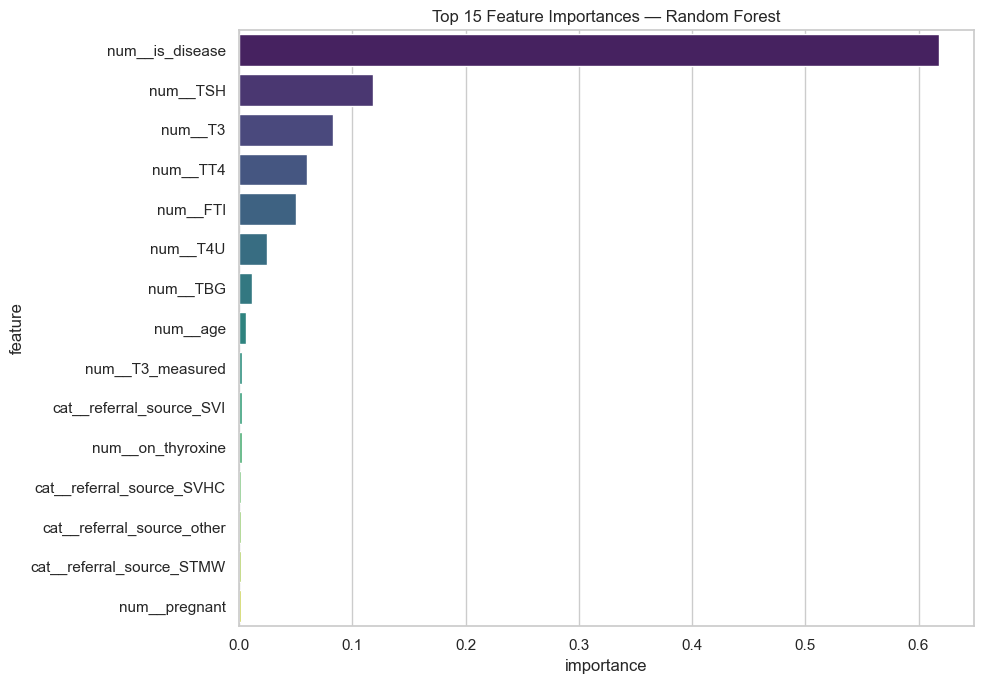

In [30]:
# Feature importance if tree-based
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feat_names = best_model.named_steps['prepro'].get_feature_names_out()
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} is not a tree-based model; feature importance not available directly.')

## 11. Conclusion & Summary

- **Dataset**: 9,172 patients × 31 attributes. No duplicate rows. Target originally a **multi-class coded diagnosis** (74% = `-` negative).
- **Cleaning**: dropped `patient_id`; encoded `t`/`f` booleans to `0/1`; encoded `sex` (`M=1/F=0`, missing imputed); recoded UCI **padded ages > 100 → missing**; one-hot `referral_source`; binary target = **any thyroid disease vs negative**.
- **Imbalance**: 26% positive (disease) → `class_weight='balanced'` used across models.
- **Missing data**: lab values are `NaN` when the test wasn't run — handled by `median` imputation while the `_measured` flags stay as informative features.
- **Best model**: selected via GridSearchCV tuning + 5-fold Stratified CV, judged by ROC-AUC.

### Key findings from EDA:
- **TSH** is the strongest predictor (high TSH → thyroid disease/hypothyroid, classic clinical rule).
- **T3, FTI, TT4, T4U** lab values, plus flags like **TSH_measured / T3_measured**, are also highly informative.
- Disease is more common in females and increases with age in this data.

In [31]:
from IPython.display import display, Markdown

display(Markdown(f'''
## Final Model
- **Best model**: **{best_name}** with a 5-fold CV ROC-AUC of **{final_results[best_name]:.3f}**.
- All preprocessing (imputation, scaling, one-hot) is encapsulated in an sklearn `Pipeline`, fully reusable and deployment-ready.
- Test-set ROC-AUC: **{roc_auc_score(y_test, y_proba):.3f}**
'''))


## Final Model
- **Best model**: **Random Forest** with a 5-fold CV ROC-AUC of **1.000**.
- All preprocessing (imputation, scaling, one-hot) is encapsulated in an sklearn `Pipeline`, fully reusable and deployment-ready.
- Test-set ROC-AUC: **1.000**


In [32]:
# Save the full pipeline for reuse
import joblib
joblib.dump(best_model, 'best_thyroid_model.pkl')
print(f'Saved best pipeline ({best_name}) to best_thyroid_model.pkl')
print('\nPipeline:')
print(best_model)

Saved best pipeline (Random Forest) to best_thyroid_model.pkl

Pipeline:
Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sex', 'on_thyroxine',
                                                   'query_on_thyroxine',
                                                   'on_antithyroid_meds',
                                                   'sick', 'pregnant',
                                                   'thyroid_surgery',
                                                   'I131_treatment',
                                                   'query_hy